In [26]:
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 2\\data\\stroop_data_template.csv')
print("Data Loaded:")
display(df.head(16))

Data Loaded:


,Participant,Accuracy,Re_Time_s,Performance
0,1,97.2,1.70,Poor
1,2,97.2,1.67,Poor
2,3,97.8,2.03,Poor
3,4,98.8,2.25,poor
4,5,100.0,1.03,Good
5,6,99.2,1.46,Good
6,7,98.2,1.07,Good
7,8,98.6,1.29,Good
8,9,93.1,2.52,Poor
9,10,96.9,1.40,Good


Available Columns: ['Participant', 'Accuracy', 'Re_Time_s ', 'Performance']


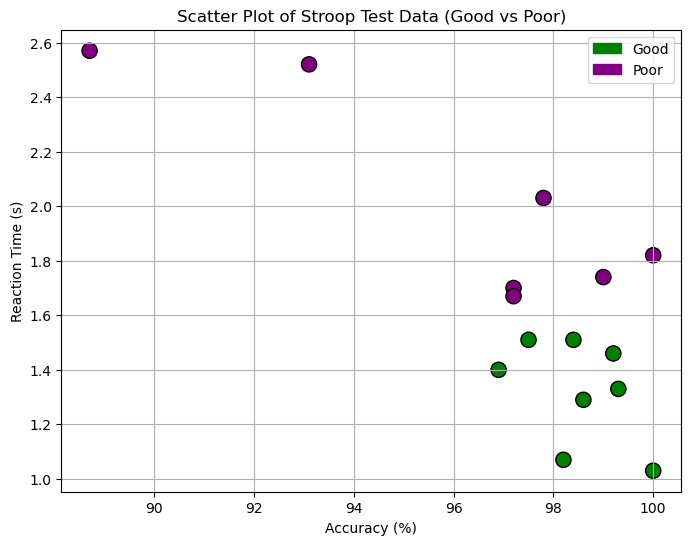

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==== Load Dataset ====
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 2\\data\\stroop_data_template.csv')

# Check column names
print("Available Columns:", df.columns.tolist())

# Map Performance to numeric
df['PerformanceLabel'] = df['Performance'].map({'Poor':0, 'Good':1})

# Drop rows where PerformanceLabel is NaN
df = df.dropna(subset=['PerformanceLabel'])

# Auto-detect columns
acc_col = [c for c in df.columns if "Acc" in c][0]
time_col = [c for c in df.columns if "Time" in c][0]

# Custom color mapping
colors = df['PerformanceLabel'].map({0:'purple', 1:'green'})

# ==== Scatter Plot ====
plt.figure(figsize=(8,6))
plt.scatter(df[acc_col], df[time_col], c=colors, s=120, edgecolor='k')

# Labels & Title
plt.xlabel("Accuracy (%)")
plt.ylabel("Reaction Time (s)")
plt.title("Scatter Plot of Stroop Test Data (Good vs Poor)")

# Legend
good_patch = mpatches.Patch(color='green', label='Good')
poor_patch = mpatches.Patch(color='purple', label='Poor')
plt.legend(handles=[good_patch, poor_patch])

plt.grid(True)
plt.show()


In [28]:
print(df.columns.tolist())


['Participant', 'Accuracy', 'Re_Time_s ', 'Performance', 'PerformanceLabel']


In [29]:
df.columns = df.columns.str.strip()

In [30]:
basic_stats = df[['Accuracy','Re_Time_s']].describe()
print(basic_stats)


         Accuracy  Re_Time_s
count   15.000000  15.000000
mean    97.406667   1.643333
std      2.936097   0.453363
min     88.700000   1.030000
25%     97.200000   1.365000
50%     98.200000   1.510000
75%     99.100000   1.780000
max    100.000000   2.570000


In [31]:
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 2\\data\\stroop_data_template.csv')
print("Data Loaded:")
display(df.head(16))


Data Loaded:


,Participant,Accuracy,Re_Time_s,Performance
0,1,97.2,1.70,Poor
1,2,97.2,1.67,Poor
2,3,97.8,2.03,Poor
3,4,98.8,2.25,poor
4,5,100.0,1.03,Good
5,6,99.2,1.46,Good
6,7,98.2,1.07,Good
7,8,98.6,1.29,Good
8,9,93.1,2.52,Poor
9,10,96.9,1.40,Good


In [32]:
import pandas as pd

# Load CSV file
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 2\\data\\stroop_data_template.csv')

# Strip extra spaces in column names
df.columns = df.columns.str.strip()

# Show first 5 rows
print(df.head())

# Define Features and Target
X = df[['Accuracy', 'Re_Time_s']]
y = df['Performance']

print("\nFeatures (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())


   Participant  Accuracy  Re_Time_s Performance
0            1      97.2       1.70        Poor
1            2      97.2       1.67        Poor
2            3      97.8       2.03        Poor
3            4      98.8       2.25        poor
4            5     100.0       1.03        Good

Features (X):
   Accuracy  Re_Time_s
0      97.2       1.70
1      97.2       1.67
2      97.8       2.03
3      98.8       2.25
4     100.0       1.03

Target (y):
0    Poor
1    Poor
2    Poor
3    poor
4    Good
Name: Performance, dtype: object


In [33]:
from sklearn.model_selection import train_test_split

# 80%-20% split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train Features:\n", X_train)
print("\nTest Features:\n", X_test)


Train Features:
     Accuracy  Re_Time_s
13     100.0       1.82
11      97.5       1.51
8       93.1       2.52
9       96.9       1.40
2       97.8       2.03
15      98.4       1.51
4      100.0       1.03
7       98.6       1.29
10      88.7       2.57
12      99.3       1.33
3       98.8       2.25
6       98.2       1.07

Test Features:
     Accuracy  Re_Time_s
0       97.2       1.70
1       97.2       1.67
5       99.2       1.46
14      99.0       1.74


In [34]:
from sklearn.neural_network import MLPClassifier

# Define Neural Network
nn_model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)

# Train the model
nn_model.fit(X_train, y_train)

# Predict on test set
y_pred_nn = nn_model.predict(X_test)

print("Neural Network Predictions:", y_pred_nn)


Neural Network Predictions: ['Good' 'Good' 'Good' 'Good']


In [35]:
from sklearn.ensemble import RandomForestClassifier

# Define Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Predictions:", y_pred_rf)


Random Forest Predictions: ['Good' 'Good' 'Good' 'Poor']


In [13]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Step 1: Load CSV
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 2\\data\\stroop_data_template.csv')

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Step 2: Make Performance column consistent
df['Performance'] = df['Performance'].str.lower()  # 'Poor' -> 'poor', 'Good' -> 'good'

# Step 3: Define Features and Target
X = df[['Accuracy','Re_Time_s']]
y = df['Performance']

# Step 4: Label encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'poor'->0, 'good'->1

# Step 5: Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Step 6: Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Step 7: Predict
y_pred_xgb = xgb_model.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred_xgb)

print("XGBoost Predictions:", y_pred_labels)


XGBoost Predictions: ['good' 'good' 'good' 'good']


C:\Users\mdjas\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:47:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\mdjas\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:45:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


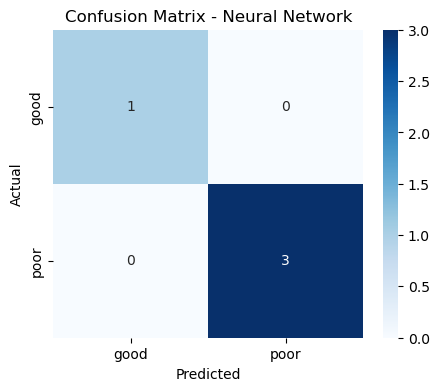

Neural Network Accuracy: 1.0


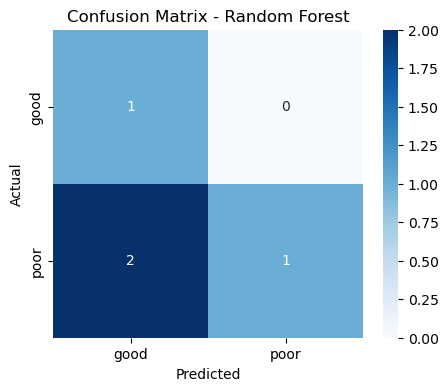

Random Forest Accuracy: 0.5


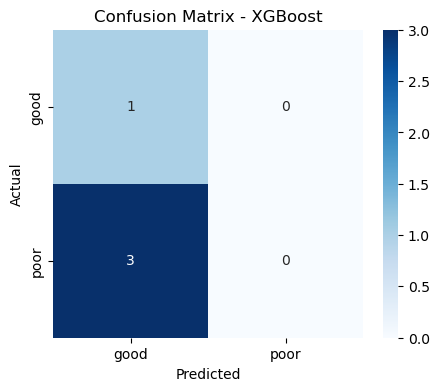

XGBoost Accuracy: 0.25


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Step 1: Load CSV dataset
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 2\\data\\stroop_data_template.csv')
df.columns = df.columns.str.strip()  # Remove extra spaces

# Step 2: Make target column consistent
df['Performance'] = df['Performance'].str.lower()  # 'Poor'/'Good' -> 'poor'/'good'

# Step 3: Features and Target
X = df[['Accuracy','Re_Time_s']]
y = df['Performance']

# Step 4: Label encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'poor'->0, 'good'->1

# Step 5: Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Step 6: Train Models
nn_model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Step 7: Function to plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    print(f"{model_name} Accuracy:", accuracy_score(y_true, y_pred))

# Step 8: Visualize All
plot_confusion_matrix(y_test, y_pred_nn, "Neural Network")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost")
